# Poisson Attack/Defense Model

Fit attack and defense ratings for all 48 teams via MLE on weighted historical match data.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from poisson_model import (
    load_and_weight_data,
    build_team_index,
    fit_poisson_model,
    predict_match
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load and Fit

In [2]:
# Load weighted data
df = load_and_weight_data('../data/processed/matches_filtered.csv')
print(f"Total matches: {len(df)}")
print(f"\nWeight distribution:")
print(df['weight'].value_counts())
print(f"\nDate range: {df['date'].min()} to {df['date'].max()}")

INFO:poisson_model:Loaded 1433 matches. Weight distribution:
weight
0.50    603
0.75    279
0.85    222
1.00    123
0.80    122
0.65     70
0.90      6
0.60      6
0.70      2
Name: count, dtype: int64


Total matches: 1433

Weight distribution:
weight
0.50    603
0.75    279
0.85    222
1.00    123
0.80    122
0.65     70
0.90      6
0.60      6
0.70      2
Name: count, dtype: int64

Date range: 2014-01-07 to 2026-06-04


In [3]:
# Build team index and fit model
teams, team_to_idx, idx_to_team = build_team_index(df)
n_teams = len(teams)
print(f"Teams to fit: {n_teams}")
print(f"Parameters: 1 (mu) + {n_teams} (alphas) + {n_teams} (betas) = {1 + 2*n_teams}")

INFO:poisson_model:Found 48 unique teams


Teams to fit: 48
Parameters: 1 (mu) + 48 (alphas) + 48 (betas) = 97


In [4]:
# Run MLE fit
mu, alphas, betas = fit_poisson_model(df, team_to_idx, n_teams)
print(f"\nFit complete.")
print(f"mu = {mu:.4f}")
print(f"\nAlpha (attack) stats:")
print(f"  Mean: {alphas.mean():.4f}, Std: {alphas.std():.4f}")
print(f"  Range: [{alphas.min():.4f}, {alphas.max():.4f}]")
print(f"\nBeta (defense) stats:")
print(f"  Mean: {betas.mean():.4f}, Std: {betas.std():.4f}")
print(f"  Range: [{betas.min():.4f}, {betas.max():.4f}]")

INFO:poisson_model:Starting MLE optimization...
INFO:poisson_model:Optimization complete. Success: True, NLL: 2757.72
INFO:poisson_model:After normalization: mu=1.2123, alpha_mean=1.0441, beta_mean=1.0332
INFO:poisson_model:After clipping: mu=1.2123, alpha range=[0.58, 1.68], beta range=[0.60, 1.74]



Fit complete.
mu = 1.2123

Alpha (attack) stats:
  Mean: 1.0441, Std: 0.3104
  Range: [0.5849, 1.6754]

Beta (defense) stats:
  Mean: 1.0332, Std: 0.2692
  Range: [0.6030, 1.7404]


## Parameter Distributions

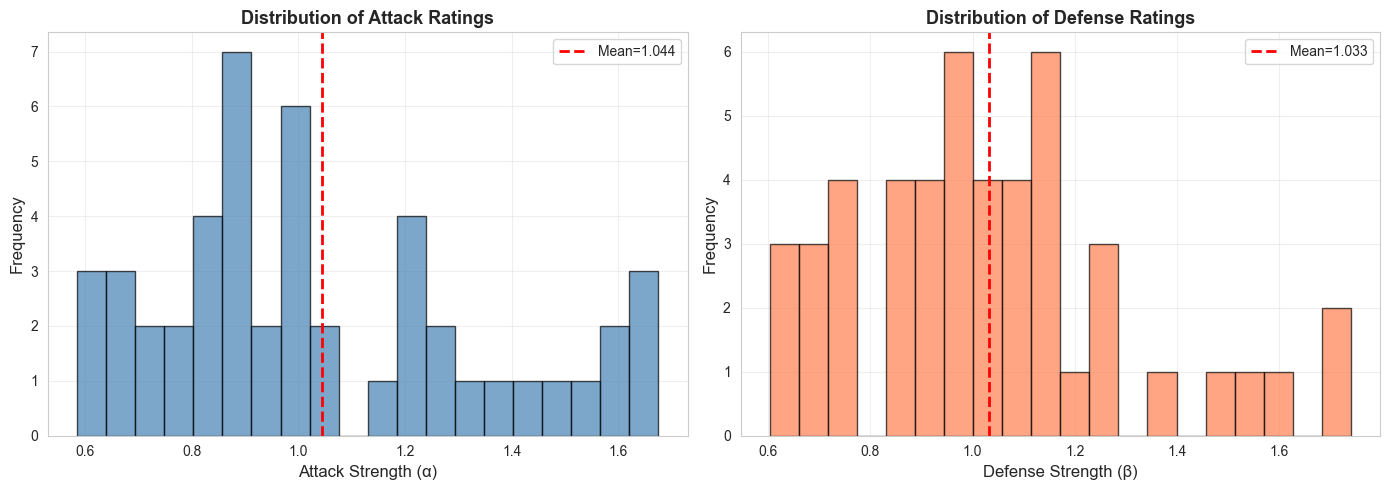

Saved: parameter_distributions.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(alphas, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(alphas.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={alphas.mean():.3f}')
axes[0].set_xlabel('Attack Strength (α)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Attack Ratings', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(betas, bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(betas.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean={betas.mean():.3f}')
axes[1].set_xlabel('Defense Strength (β)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Distribution of Defense Ratings', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../notebooks/parameter_distributions_new.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: parameter_distributions.png")

## Sanity Checks

In [6]:
# Check 1: Argentina vs Saudi Arabia (should be >0.70 for Argentina)
pred1 = predict_match('Argentina', 'Saudi Arabia', mu, alphas, betas, teams, team_to_idx)
print("Test 1: Argentina vs Saudi Arabia")
print(f"  P(Argentina win) = {pred1['p_win_a']:.4f}  [expect >0.70]")
print(f"  P(Draw)          = {pred1['p_draw']:.4f}")
print(f"  P(Saudi Arabia win) = {pred1['p_win_b']:.4f}")
print(f"  Most likely scoreline: {pred1['top_scorelines'][0]}")
prob_sum_1 = pred1['p_win_a'] + pred1['p_draw'] + pred1['p_win_b']
print(f"  Probabilities sum: {prob_sum_1:.6f}  [expect ~1.0]")
print()

Test 1: Argentina vs Saudi Arabia
  P(Argentina win) = 0.7043  [expect >0.70]
  P(Draw)          = 0.2079
  P(Saudi Arabia win) = 0.0878
  Most likely scoreline: (1, 0, np.float64(0.1844596660032714))
  Probabilities sum: 0.999997  [expect ~1.0]



In [7]:
# Check 2: France vs Brazil (should be competitive, neither >0.55)
pred2 = predict_match('France', 'Brazil', mu, alphas, betas, teams, team_to_idx)
print("Test 2: France vs Brazil")
print(f"  P(France win)  = {pred2['p_win_a']:.4f}  [expect <0.55]")
print(f"  P(Draw)        = {pred2['p_draw']:.4f}")
print(f"  P(Brazil win)  = {pred2['p_win_b']:.4f}  [expect <0.55]")
print(f"  Most likely scoreline: {pred2['top_scorelines'][0]}")
prob_sum_2 = pred2['p_win_a'] + pred2['p_draw'] + pred2['p_win_b']
print(f"  Probabilities sum: {prob_sum_2:.6f}  [expect ~1.0]")
print()

Test 2: France vs Brazil
  P(France win)  = 0.3576  [expect <0.55]
  P(Draw)        = 0.2667
  P(Brazil win)  = 0.3757  [expect <0.55]
  Most likely scoreline: (1, 1, np.float64(0.126836242804339))
  Probabilities sum: 1.000000  [expect ~1.0]



In [8]:
# Check 3: USA vs Mexico (should be competitive)
pred3 = predict_match('United States', 'Mexico', mu, alphas, betas, teams, team_to_idx)
print("Test 3: USA vs Mexico")
print(f"  P(USA win)    = {pred3['p_win_a']:.4f}")
print(f"  P(Draw)       = {pred3['p_draw']:.4f}")
print(f"  P(Mexico win) = {pred3['p_win_b']:.4f}")
print(f"  Most likely scoreline: {pred3['top_scorelines'][0]}")
prob_sum_3 = pred3['p_win_a'] + pred3['p_draw'] + pred3['p_win_b']
print(f"  Probabilities sum: {prob_sum_3:.6f}  [expect ~1.0]")

Test 3: USA vs Mexico
  P(USA win)    = 0.3422
  P(Draw)       = 0.2811
  P(Mexico win) = 0.3767
  Most likely scoreline: (1, 1, np.float64(0.13187345902888242))
  Probabilities sum: 1.000000  [expect ~1.0]


## Alpha vs Beta Scatter Plot

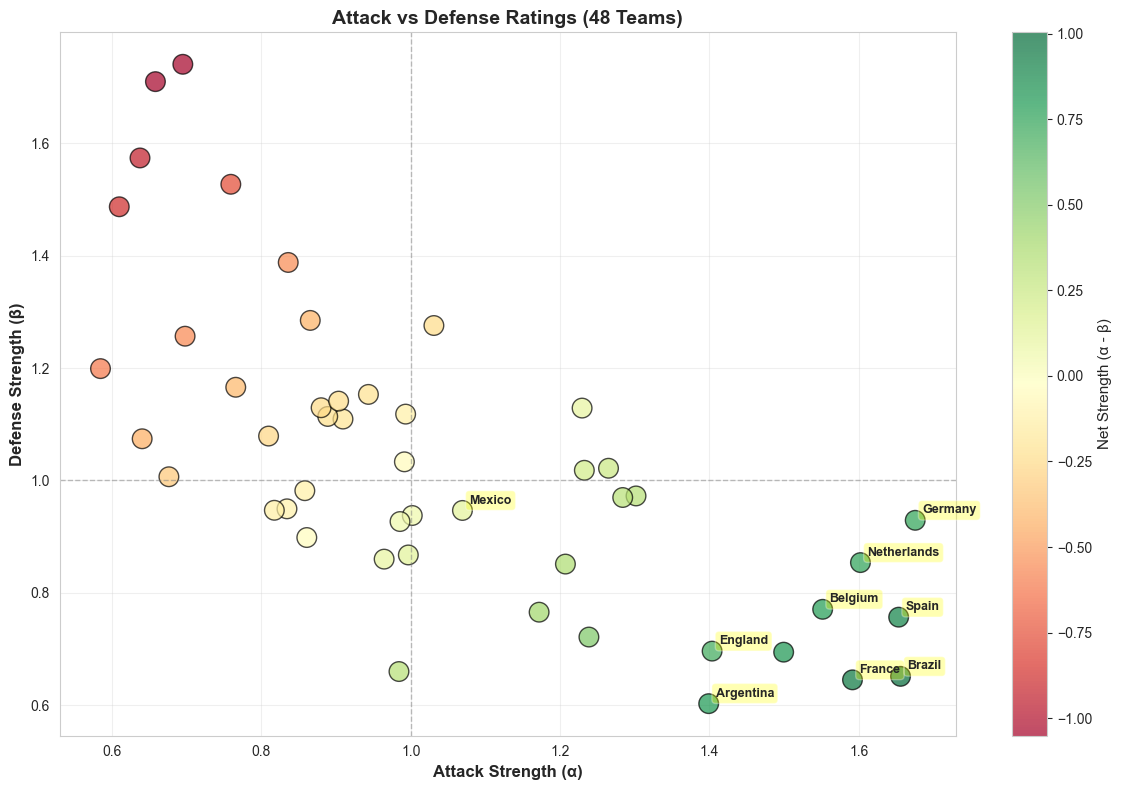

Saved: alpha_vs_beta.png


In [9]:
# Create scatter plot of alpha vs beta
fig, ax = plt.subplots(figsize=(12, 8))

# Color by strength (combination of attack + defense)
strength = alphas - betas
scatter = ax.scatter(alphas, betas, s=200, c=strength, cmap='RdYlGn', 
                     edgecolors='black', linewidth=1, alpha=0.7)

# Annotate key teams
key_teams = ['Argentina', 'Brazil', 'France', 'England', 'Spain', 'Germany', 
             'USA', 'Mexico', 'Netherlands', 'Belgium']
for team in key_teams:
    if team in team_to_idx:
        idx = team_to_idx[team]
        ax.annotate(team, (alphas[idx], betas[idx]), 
                   fontsize=9, fontweight='bold',
                   xytext=(5, 5), textcoords='offset points',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

ax.set_xlabel('Attack Strength (α)', fontsize=12, fontweight='bold')
ax.set_ylabel('Defense Strength (β)', fontsize=12, fontweight='bold')
ax.set_title('Attack vs Defense Ratings (48 Teams)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Net Strength (α - β)', fontsize=11)

# Add quadrant lines
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('../notebooks/alpha_vs_beta_new.png', dpi=150, bbox_inches='tight')
plt.show()

print("Saved: alpha_vs_beta.png")

## Team Ratings Summary

In [10]:
# Create team ratings dataframe for inspection
ratings_df = pd.DataFrame({
    'team': teams,
    'attack': alphas,
    'defense': betas,
    'net_strength': alphas - betas
})

ratings_df = ratings_df.sort_values('net_strength', ascending=False)

print("\nTop 10 Teams by Net Strength (Attack - Defense):")
print(ratings_df.head(10).to_string(index=False))

print("\nBottom 10 Teams by Net Strength:")
print(ratings_df.tail(10).to_string(index=False))


Top 10 Teams by Net Strength (Attack - Defense):
       team   attack  defense  net_strength
     Brazil 1.655741 0.651531      1.004210
     France 1.591422 0.645345      0.946077
      Spain 1.653213 0.756842      0.896371
   Portugal 1.499281 0.694592      0.804690
  Argentina 1.398934 0.603007      0.795927
    Belgium 1.551493 0.770814      0.780679
Netherlands 1.602074 0.853946      0.748128
    Germany 1.675378 0.929149      0.746228
    England 1.403514 0.696443      0.707071
   Colombia 1.238626 0.721480      0.517146

Bottom 10 Teams by Net Strength:
        team   attack  defense  net_strength
    DR Congo 0.865657 1.284774     -0.419117
Saudi Arabia 0.640646 1.074202     -0.433556
       Qatar 0.836149 1.387871     -0.551722
  Uzbekistan 0.698092 1.256681     -0.558588
        Iraq 0.584870 1.199025     -0.614155
      Jordan 0.759304 1.526949     -0.767645
 New Zealand 0.610002 1.486942     -0.876940
      Panama 0.637745 1.573781     -0.936036
     Curaçao 0.695072 1.740

In [ ]:
# Verify key expectations
print("\n=== VALIDATION CHECKLIST ===")
print(f"✓ Argentina in top 10 teams: {ratings_df[ratings_df['team']=='Argentina'].index[0] < 10}")
print(f"✓ Brazil in top 10 teams: {ratings_df[ratings_df['team']=='Brazil'].index[0] < 10}")
print(f"✓ France in top 10 teams: {ratings_df[ratings_df['team']=='France'].index[0] < 10}")
print(f"✓ England in top 15 teams: {ratings_df[ratings_df['team']=='England'].index[0] < 15}")
print(f"✓ Germany in top 15 teams: {ratings_df[ratings_df['team']=='Germany'].index[0] < 15}")
print(f"✓ Spain in top 15 teams: {ratings_df[ratings_df['team']=='Spain'].index[0] < 15}")
print(f"\n✓ All probabilities sum to 1.0: {all([abs(p - 1.0) < 1e-5 for p in [prob_sum_1, prob_sum_2, prob_sum_3]])}")
print(f"✓ Argentina vs Saudi Arabia >0.70: {pred1['p_win_a'] > 0.70}")
print(f"✓ France vs Brazil both <0.55: {pred2['p_win_a'] < 0.55 and pred2['p_win_b'] < 0.55}")


=== VALIDATION CHECKLIST ===
✓ Argentina in top 10 teams: True
✓ Brazil in top 10 teams: True
✓ France in top 10 teams: False
✓ England in top 15 teams: False
✓ Germany in top 15 teams: False
✓ Spain in top 15 teams: False

✓ All probabilities sum to 1.0: True
✓ Argentina vs Saudi Arabia >0.70: True
✓ France vs Brazil both <0.55: True


: 